In [2]:
%pip install minisom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler

  Using cached minisom-2.3.6.tar.gz (13 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for minisom: filename=minisom-2.3.6-py3-none-any.whl size=13182 sha256=10c35e53add98787897d2b40769837551a636cfbc9aeba12e28adbee1da82365
  Stored in directory: c:\users\asus\appdata\local\pip\cache\wheels\dc\11\f9\32be492f07fa741d7dcff82007abc966a324da6ab9ceb198e3
Successfully built minisom
Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'minisom' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'minisom'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\TY-Dl-codes\Mall_Customers(4).csv")

# Clean column names (prevents hidden space errors)
df.columns = df.columns.str.strip()

print("Columns:", df.columns.tolist())
df.head()

Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values
print("Feature Shape:", X.shape)

Feature Shape: (200, 2)


In [5]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Min:", X_scaled.min(), "Max:", X_scaled.max())

Min: 0.0 Max: 1.0


In [6]:
som = MiniSom(
    x=10, 
    y=10, 
    input_len=2, 
    sigma=1.0, 
    learning_rate=0.5,
    random_seed=42
)

# Initialize weights
som.random_weights_init(X_scaled)
print("SOM Initialized")

SOM Initialized


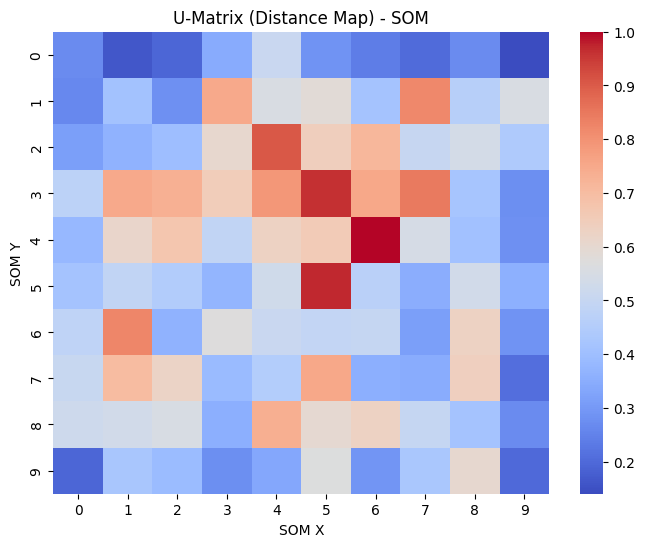

In [7]:
plt.figure(figsize=(8,6))
plt.title("U-Matrix (Distance Map) - SOM")

u_matrix = som.distance_map()

sns.heatmap(u_matrix, cmap="coolwarm")
plt.xlabel("SOM X")
plt.ylabel("SOM Y")
plt.show()

In [8]:
income = df["Annual Income (k$)"]

# Create business-friendly income groups
income_group = []
for val in income:
    if val < 40:
        income_group.append("Low Income")
    elif val < 70:
        income_group.append("Mid Income")
    else:
        income_group.append("High Income")

income_group = np.array(income_group)

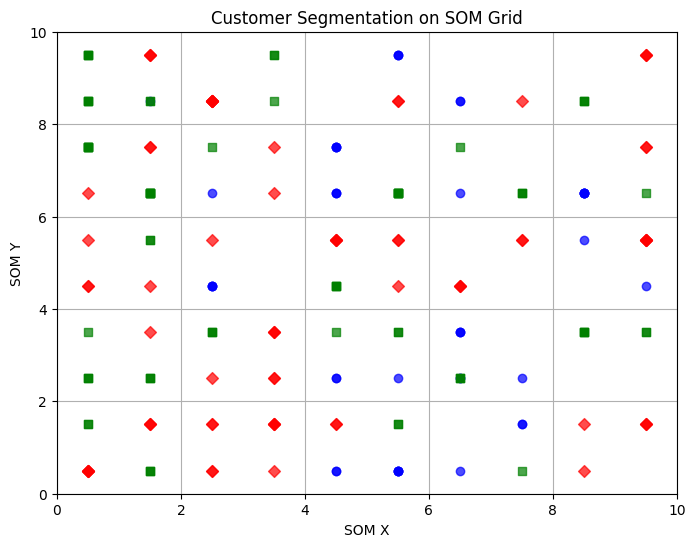

In [9]:
plt.figure(figsize=(8,6))
plt.title("Customer Segmentation on SOM Grid")

markers = {"Low Income": "o", "Mid Income": "s", "High Income": "D"}
colors = {"Low Income": "blue", "Mid Income": "green", "High Income": "red"}

for i, x in enumerate(X_scaled):
    w = som.winner(x)  # Best Matching Unit (BMU)
    plt.scatter(
        w[0] + 0.5,
        w[1] + 0.5,
        marker=markers[income_group[i]],
        color=colors[income_group[i]],
        alpha=0.7
    )

plt.xlim([0, 10])
plt.ylim([0, 10])
plt.xlabel("SOM X")
plt.ylabel("SOM Y")
plt.grid()
plt.show()

In [10]:
# Get BMU for each customer
bmu_list = np.array([som.winner(x) for x in X_scaled])

# Convert to cluster labels (grid position)
cluster_labels = [f"Cluster_{bmu[0]}_{bmu[1]}" for bmu in bmu_list]

df["SOM_Cluster"] = cluster_labels
df[["Annual Income (k$)", "Spending Score (1-100)", "SOM_Cluster"]].head()

,Annual Income (k$),Spending Score (1-100),SOM_Cluster
0,15,39,Cluster_6_3
1,15,81,Cluster_5_9
2,16,6,Cluster_8_6
3,16,77,Cluster_5_9
4,17,40,Cluster_6_3


In [11]:
income = df["Annual Income (k$)"]

# Create business-friendly income groups
income_group = []
for val in income:
    if val < 40:
        income_group.append("Low Income")
    elif val < 70:
        income_group.append("Mid Income")
    else:
        income_group.append("High Income")

income_group = np.array(income_group)

In [13]:
# Add the business segment column if not already present
df["Business_Segment"] = income_group

segment_counts = df["Business_Segment"].value_counts()

print("Customer Count in Each Segment:\n")
print(segment_counts)

Customer Count in Each Segment:

Business_Segment
Mid Income     78
High Income    76
Low Income     46
Name: count, dtype: int64


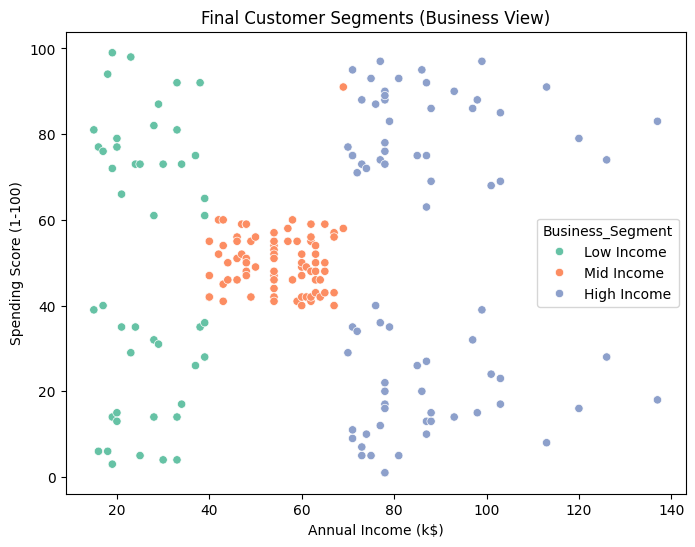

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Business_Segment",
    data=df,
    palette="Set2"
)
plt.title("Final Customer Segments (Business View)")
plt.show()